# [KDD 2026 AI4Sci] StageGuard - train + decode demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Q9gJYx/StageGuard/blob/main/notebooks/demo_stageguard.ipynb)
[![KDD 2026](https://img.shields.io/badge/KDD-2026%20AI4Sci-1d4ed8.svg)](https://doi.org/10.1145/3770855.3818916)
[![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://github.com/Q9gJYx/StageGuard/blob/main/LICENSE)

**StageGuard** wraps any neural sleep-staging backbone with physiology-informed priors: a differentiable
**soft transition penalty** at training time and a **semi-Markov constrained decoder** at inference time.

This notebook **actually trains** the repository's real **AccuSleep** backbone on **real mouse EEG**, then:

1. trains the backbone with class-balanced cross-entropy **plus the soft transition penalty**,
2. decodes a held-out night with the **semi-Markov decoder**, and
3. shows the **transition-violation rate (TVR)** and **fragmentation index (FI)** drop while accuracy is held or improved.

The backbone is trained **EEG-only** (no EMG). Without muscle tone the model cannot cleanly separate Wake from
REM (both are low-amplitude/theta in mice), so its raw output confuses Wake<->REM and fragments bouts - exactly
the physiologically implausible errors StageGuard is designed to repair.

## Setup

On Colab this clones the repo and installs the package. Locally (run from the repo root) it is a no-op.

> **Network + compute.** This notebook downloads one ~233 MB mouse recording from the public AccuSleep dataset
> and trains for a few short epochs - roughly **3-5 minutes on a Colab CPU**. No GPU is required, and **no raw
> data is shipped in this repository** (the recordings are downloaded at runtime from their open OSF project).

In [1]:
import os, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("StageGuard"):
        !git clone -q https://github.com/Q9gJYx/StageGuard.git
    %cd StageGuard
    !pip install -q -e .
# Ensure cwd is the repo root so configs/ resolve when run locally.
if not os.path.exists("configs") and os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Running in Colab:", IN_COLAB)

Running in Colab: False


In [2]:
import os, glob, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy.io import loadmat
from scipy.signal import decimate

from stageguard.config import ModalityConfig
from stageguard.backbones import get_backbone
from stageguard.wrapper import StageGuardWrapper
from stageguard.losses import SoftTransitionPenalty
from stageguard.decoder import SemiMarkovDecoder
from stageguard.metrics import (
    transition_violation_rate, fragmentation_index,
    classification_metrics, sleep_architecture,
)

SEED = 1
torch.manual_seed(SEED); np.random.seed(SEED)

# AccuSleep demo data - downloaded at runtime; nothing is shipped in the repo.
OSF_FILE_ID = "5d9fdbfff6b03e000d1cb300"   # Mouse03.zip on OSF project py5eb
CACHE_DIR = "accusleep_data"
FS_RAW, DS = 512, 4                        # decimate 512 -> 128 Hz
EPOCH_SEC = 2.5                            # AccuSleep native epoch length
SPE = int(FS_RAW // DS * EPOCH_SEC)        # 320 samples per epoch at 128 Hz
STAGE_NAMES = ["Wake", "NREM", "REM"]
REMAP = {2: 0, 3: 1, 1: 2}                 # AccuSleep 1=REM,2=Wake,3=NREM -> Wake,NREM,REM
TRAIN_DAYS, EVAL_DAY = [2, 3, 4, 5], 1     # train on four nights, test a held-out night

## Data: real mouse EEG (AccuSleep)

We use the open [AccuSleep](https://github.com/zekebarger/AccuSleep) mouse EEG/EMG dataset (Barger et al. 2019),
hosted on [OSF](https://osf.io/py5eb/). One mouse (`Mouse03`) has five nightly recordings of EEG/EMG at 512 Hz
with expert 2.5 s sleep-stage labels (Wake / NREM / REM). The OSF project carries no redistribution license, so
the notebook **downloads** it at runtime rather than shipping it. We train the backbone on **four nights** and
evaluate it on a **held-out night** - a genuine cross-recording test with no train/test leakage.

In [3]:
os.makedirs(CACHE_DIR, exist_ok=True)
zip_path = os.path.join(CACHE_DIR, "Mouse03.zip")
if not (os.path.exists(zip_path) and os.path.getsize(zip_path) > 2e8):
    url = f"https://osf.io/download/{OSF_FILE_ID}/"
    print(f"Downloading Mouse03.zip (~233 MB) from {url} ...")
    req = urllib.request.Request(url, headers={"User-Agent": "stageguard-demo/1.0"})
    with urllib.request.urlopen(req, timeout=180) as r, open(zip_path, "wb") as f:
        while True:
            chunk = r.read(1 << 20)
            if not chunk:
                break
            f.write(chunk)
assert os.path.getsize(zip_path) > 2e8, "download looks truncated; re-run this cell"
if not glob.glob(os.path.join(CACHE_DIR, "**", "Day*", ""), recursive=True):
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(CACHE_DIR)
session_dirs = sorted(glob.glob(os.path.join(CACHE_DIR, "**", "Day*", ""), recursive=True))
print(f"{len(session_dirs)} nightly sessions found")

5 nightly sessions found


In [4]:
def load_mat_var(path, name):
    # Load one variable from a .mat file (v7 via scipy, v7.3/HDF5 via h5py).
    try:
        return np.asarray(loadmat(path)[name]).squeeze()
    except NotImplementedError:
        import h5py
        with h5py.File(path, "r") as f:
            return np.asarray(f[name]).squeeze()

def load_session(day_dir):
    # Return (epochs (n, SPE) float32, labels (n,) in {0,1,2}) for one night.
    eeg = load_mat_var(os.path.join(day_dir, "EEG.mat"), "EEG").astype(np.float64)
    lab = load_mat_var(os.path.join(day_dir, "labels.mat"), "labels").astype(int)
    eeg = decimate(eeg, DS, ftype="fir")             # anti-aliased downsample 512 -> 128 Hz
    n = len(lab)
    epochs = eeg[: n * SPE].reshape(n, SPE).astype(np.float32)
    y = np.array([REMAP[v] for v in lab], dtype=np.int64)
    return epochs, y

Xtr, ytr = [], []
for d in TRAIN_DAYS:
    x, y = load_session(session_dirs[d - 1]); Xtr.append(x); ytr.append(y)
Xtr = np.concatenate(Xtr); ytr = np.concatenate(ytr)
Xva, yva = load_session(session_dirs[EVAL_DAY - 1])

mu, sd = Xtr.mean(), Xtr.std() + 1e-8                 # z-score with TRAIN statistics only
Xtr = (Xtr - mu) / sd; Xva = (Xva - mu) / sd

def dist(y):
    return {STAGE_NAMES[i]: int((y == i).sum()) for i in range(3)}
print(f"train: {len(ytr):5d} epochs  {dist(ytr)}")
print(f"eval : {len(yva):5d} epochs  {dist(yva)}  (held-out night)")
assert set(np.unique(yva).tolist()) == {0, 1, 2}, "held-out night must contain all three stages" 

train: 23040 epochs  {'Wake': 5989, 'NREM': 14039, 'REM': 3012}
eval :  5760 epochs  {'Wake': 1431, 'NREM': 3478, 'REM': 851}  (held-out night)


## Train the AccuSleep backbone (with the soft transition penalty)

The loss is **class-balanced cross-entropy** (mouse REM is only ~15% of epochs) **plus StageGuard's
differentiable `SoftTransitionPenalty`**, which discourages probability mass on rare Wake<->REM transitions.
The backbone is the repository's compact AccuSleep CNN (~21k parameters), trained EEG-only on short epoch
windows. A few passes on CPU are enough to make the point.

In [5]:
config = ModalityConfig.from_yaml("configs/accusleep_demo.yaml")
backbone = get_backbone("accusleep", num_classes=config.num_classes, in_channels=1)
model = StageGuardWrapper(backbone, config)
penalty = SoftTransitionPenalty(config.rare_transitions)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

freq = np.bincount(ytr, minlength=3).astype(float)   # class-balanced CE weights
inv = 1.0 / np.sqrt(freq)
weight = torch.tensor(inv / inv.sum() * 3, dtype=torch.float32)

T, B, EPOCHS = 20, 16, 8
nw = len(ytr) // T
Xw = torch.tensor(Xtr[: nw * T].reshape(nw, T, 1, SPE))
yw = torch.tensor(ytr[: nw * T].reshape(nw, T))
xva = torch.tensor(Xva[None, :, None, :])            # (1, T_eval, 1, SPE)

for ep in range(EPOCHS):
    model.train(); perm = torch.randperm(nw); losses = []
    for i in range(0, nw, B):
        idx = perm[i : i + B]
        logits = model(Xw[idx])
        ce = F.cross_entropy(logits.reshape(-1, 3), yw[idx].reshape(-1), weight=weight)
        loss = ce + config.lambda_trans * penalty(logits)
        opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        va_acc = float((model(xva)[0].argmax(-1).numpy() == yva).mean())
    print(f"epoch {ep + 1}/{EPOCHS}  train_loss={np.mean(losses):.4f}  val_acc={va_acc:.4f}")

epoch 1/8  train_loss=1.0395  val_acc=0.6038


epoch 2/8  train_loss=0.9512  val_acc=0.6424


epoch 3/8  train_loss=0.7973  val_acc=0.7172


epoch 4/8  train_loss=0.6640  val_acc=0.7747


epoch 5/8  train_loss=0.5594  val_acc=0.8429


epoch 6/8  train_loss=0.4722  val_acc=0.8540


epoch 7/8  train_loss=0.4172  val_acc=0.8609


epoch 8/8  train_loss=0.3816  val_acc=0.8670


In [6]:
model.eval()
with torch.no_grad():
    logits = model(xva)[0].numpy()
argmax_pred = logits.argmax(axis=1)                  # unconstrained backbone output
sg_pred = model.predict(xva)[0]                      # StageGuard semi-Markov decode
print("predictions:", argmax_pred.shape, sg_pred.shape)

predictions: (5760,) (5760,)


## Metrics: constraints satisfied, accuracy preserved

The decoder cannot add rare transitions or fragmentation, so TVR and FI can only go down; the interesting
question is whether accuracy survives. It does - and the derived **awakenings** count (a fragmentation proxy
the decoder never optimizes for) moves sharply toward the ground truth.

In [7]:
def summarize(name, pred):
    cm = classification_metrics(yva, pred, STAGE_NAMES)
    return dict(name=name,
                TVR=transition_violation_rate(pred, config.rare_transitions),
                FI_per_h=fragmentation_index(pred) * 3600.0 / EPOCH_SEC,
                acc=cm["accuracy"], kappa=cm["kappa"], remF1=cm.get("f1_REM", float("nan")))

rows = [summarize("Unconstrained (argmax)", argmax_pred),
        summarize("StageGuard decode", sg_pred),
        summarize("Ground truth", yva)]
print(f"{'method':24s} {'TVR':>7} {'FI/h':>7} {'acc':>7} {'kappa':>7} {'REM F1':>7}")
for r in rows:
    print(f"{r['name']:24s} {r['TVR']:7.3f} {r['FI_per_h']:7.1f} "
          f"{r['acc']:7.3f} {r['kappa']:7.3f} {r['remF1']:7.3f}")

print("\nDerived sleep architecture (awakenings is a fragmentation proxy, not optimized by the decoder):")
for name, pred in [("argmax", argmax_pred), ("StageGuard", sg_pred), ("truth", yva)]:
    a = sleep_architecture(pred, epoch_sec=EPOCH_SEC, wake_label=0, stage_names=STAGE_NAMES)
    print(f"  {name:11s} TST={a['tst_min']:6.1f} min  SE={a['sleep_efficiency']:.2f}  "
          f"WASO={a['waso_min']:5.1f} min  awakenings={a['awakenings']:.0f}")

method                       TVR    FI/h     acc   kappa  REM F1
Unconstrained (argmax)     0.065   268.3   0.867   0.756   0.802
StageGuard decode          0.004    54.8   0.926   0.862   0.939
Ground truth               0.004    51.5   1.000   1.000   1.000

Derived sleep architecture (awakenings is a fragmentation proxy, not optimized by the decoder):
  argmax      TST= 187.4 min  SE=0.78  WASO= 52.6 min  awakenings=498
  StageGuard  TST= 192.3 min  SE=0.80  WASO= 47.7 min  awakenings=95
  truth       TST= 180.4 min  SE=0.75  WASO= 59.6 min  awakenings=90


In [8]:
# Guard: fail loudly if the demo's story regresses. Relative checks are robust across
# seeds and recordings - the decoder may only remove rare transitions and fragmentation,
# and must not cost accuracy.
tvr_a, tvr_s = rows[0]["TVR"], rows[1]["TVR"]
fi_a, fi_s = rows[0]["FI_per_h"], rows[1]["FI_per_h"]
acc_a, acc_s = rows[0]["acc"], rows[1]["acc"]
assert fi_s <= fi_a, (fi_a, fi_s)
assert tvr_s <= tvr_a, (tvr_a, tvr_s)
assert acc_s >= acc_a - 0.02, (acc_a, acc_s)
print(f"guard OK: TVR {tvr_a:.3f} -> {tvr_s:.3f}   FI/h {fi_a:.0f} -> {fi_s:.0f}   "
      f"accuracy {acc_a:.3f} -> {acc_s:.3f}")

guard OK: TVR 0.065 -> 0.004   FI/h 268 -> 55   accuracy 0.867 -> 0.926


## The two hypnograms vs ground truth

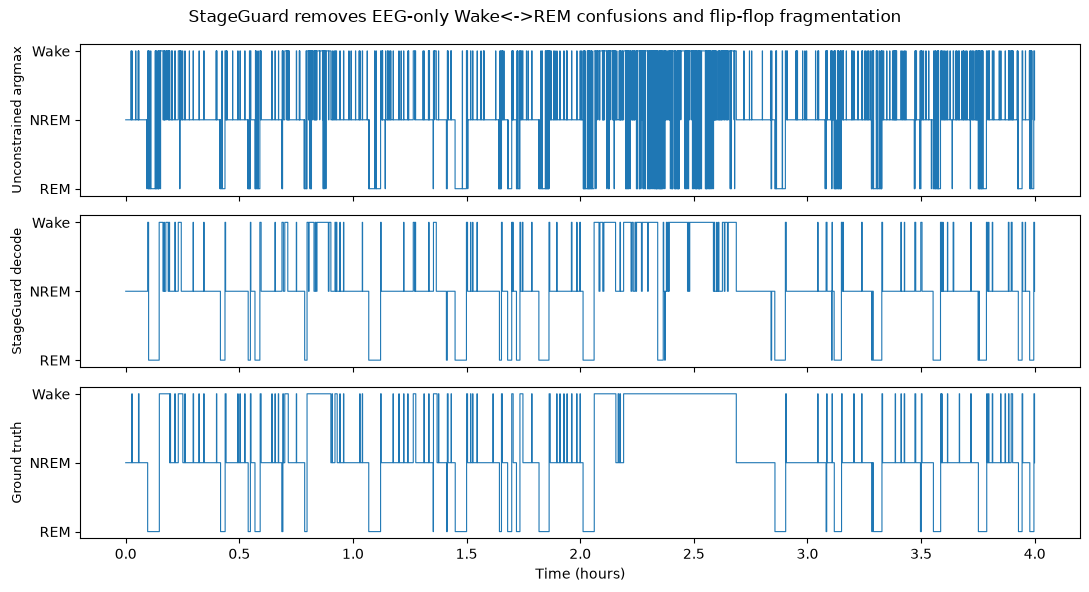

In [9]:
T_eval = len(yva)
t_h = np.arange(T_eval) * EPOCH_SEC / 3600.0
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for ax, (title, seq) in zip(axes, [("Unconstrained argmax", argmax_pred),
                                   ("StageGuard decode", sg_pred),
                                   ("Ground truth", yva)]):
    ax.step(t_h, seq, where="post", lw=0.8)
    ax.set_yticks(range(3)); ax.set_yticklabels(STAGE_NAMES)
    ax.set_ylabel(title, fontsize=9); ax.invert_yaxis()   # Wake on top
axes[-1].set_xlabel("Time (hours)")
fig.suptitle("StageGuard removes EEG-only Wake<->REM confusions and flip-flop fragmentation")
fig.tight_layout(); plt.show()

## Signal-quality integration

Per-epoch signal-quality (SQI) scores let the decoder discount low-quality epochs: emissions are damped toward
uniform where SQI is low, so the physiological priors take over. Below, a short window inside a REM bout is
overwritten with confident-but-wrong "Wake" emissions. With full trust the decoder follows the corruption;
with low SQI over that window, the rare Wake<->REM prior preserves REM.

In [10]:
decoder = SemiMarkovDecoder(config)
log_probs = torch.log_softmax(torch.tensor(logits), dim=-1).numpy().astype(np.float64)

def runs_of(seq):
    out, i = [], 0
    while i < len(seq):
        j = i + 1
        while j < len(seq) and seq[j] == seq[i]:
            j += 1
        out.append((i, j, int(seq[i]))); i = j
    return out

rem = STAGE_NAMES.index("REM")
i0, j0, _ = max((r for r in runs_of(yva) if r[2] == rem), key=lambda r: r[1] - r[0])
L = 8; a = i0 + ((j0 - i0) - L) // 2; b = a + L

lp_bad = log_probs.copy()
lp_bad[a:b, :] = np.log([0.90, 0.02, 0.08])          # confident-wrong "Wake" over a REM window
sqi = np.ones(T_eval); sqi[a:b] = 0.05               # mark that window low-quality (scores in [0, 1])

acc_win = lambda p: float((p[a:b] == yva[a:b]).mean())
print(f"REM-bout artifact window [{a}:{b}] REM accuracy  ->  "
      f"no SQI: {acc_win(decoder.decode(lp_bad)):.2f}   with SQI: {acc_win(decoder.decode(lp_bad, sqi)):.2f}")
assert acc_win(decoder.decode(lp_bad, sqi)) > acc_win(decoder.decode(lp_bad)), "SQI should recover the window" 

REM-bout artifact window [1573:1581] REM accuracy  ->  no SQI: 0.00   with SQI: 1.00


## Next steps

- Wrap your own backbone (any `nn.Module` returning `(B, T, C)` logits) - see
  [`docs/backbones.md`](https://github.com/Q9gJYx/StageGuard/blob/main/docs/backbones.md).
- Real datasets and access notes - see
  [`docs/datasets.md`](https://github.com/Q9gJYx/StageGuard/blob/main/docs/datasets.md).
- Reproduce this demo's data step locally with `python scripts/build_accusleep_demo.py`.
- Paper: *StageGuard: Physiologically Constrained Sleep Staging*, KDD 2026 AI4Sciences,
  DOI [10.1145/3770855.3818916](https://doi.org/10.1145/3770855.3818916). Archival DOI (Zenodo): _pending_.
- Please cite via [`CITATION.cff`](https://github.com/Q9gJYx/StageGuard/blob/main/CITATION.cff).